# Multimodal Fusion Weight Search

This notebook aims to automatically find the best weighting strategy for multimodal fusion by varying the `alpha` parameter for voice embeddings. It will load pre-extracted face and voice embeddings, perform a systematic search, and then train a final model with the optimal `alpha` value.

In [ ]:
# Mount Google Drive to access data files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install necessary libraries
!pip install tensorflow focal-loss scikit-learn numpy

In [ ]:
# Import essential libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
from focal_loss import SparseCategoricalFocalLoss

print("Libraries loaded successfully.")

Libraries loaded successfully.


## PART 1 - Load Data

Load face and voice embeddings along with their corresponding labels. Verify their shapes, data types, and class distributions.

In [ ]:
# Define the path to your data files
data_path = '/content/drive/MyDrive/'

try:
    face_embeddings = np.load(f'{data_path}Face_Embeddings_Output/face_embeddings.npy')
    face_labels = np.load(f'{data_path}Face_Embeddings_Output/face_labels.npy')
    voice_embeddings = np.load(f'{data_path}Voice_Embeddings_Output/voice_embeddings.npy')
    voice_labels = np.load(f'{data_path}Voice_Embeddings_Output/voice_labels.npy')

    print("Data loaded successfully!")
except FileNotFoundError:
    print(f"Error: Ensure your .npy files are uploaded to the specified path: {data_path}")
    print("Specifically, check 'Face_Embeddings_Output/face_embeddings.npy', 'Face_Embeddings_Output/face_labels.npy', etc.")
    # Exit or handle gracefully if files are not found
    raise

print(f"\nFace embeddings shape: {face_embeddings.shape}")
print(f"Face labels shape: {face_labels.shape}")
print(f"Voice embeddings shape: {voice_embeddings.shape}")
print(f"Voice labels shape: {voice_labels.shape}")

print(f"\nFace embeddings dtype: {face_embeddings.dtype}")
print(f"Face labels dtype: {face_labels.dtype}")
print(f"Voice embeddings dtype: {voice_embeddings.dtype}")
print(f"Voice labels dtype: {voice_labels.dtype}")

print("\nFace labels unique values and counts:")
print(pd.Series(face_labels).value_counts().sort_index())

print("\nVoice labels unique values and counts:")
print(pd.Series(voice_labels).value_counts().sort_index())

Data loaded successfully!

Face embeddings shape: (63568, 1280)
Face labels shape: (63568,)
Voice embeddings shape: (11490, 384)
Voice labels shape: (11490,)

Face embeddings dtype: float32
Face labels dtype: int64
Voice embeddings dtype: float32
Voice labels dtype: int64

Face labels unique values and counts:
0     9272
1     5402
2     8514
3    13029
4    11161
5     9660
6     6530
Name: count, dtype: int64

Voice labels unique values and counts:
0    1863
1    1863
2    1863
3    1863
4    1583
5    1863
6     592
Name: count, dtype: int64


## PART 2 - Fixed Splits

Create a single, stratified train/validation/test split (70%/15%/15%). This split will be reused consistently across all weight experiments for fair comparison.

In [ ]:
unique_classes = np.unique(face_labels) # Assuming face_labels define the full set of classes
num_classes = len(unique_classes)

# For initial splitting, we need a common set of labels and corresponding indices.
# Since we'll be pairing face and voice based on classes, we first create a baseline
# fused dataset (with alpha=1.0) to get the 'fused_labels' for the initial split.
# This ensures the split is stratified across the classes present in the final fused data.

# Function to create fused dataset (defined later in Part 3, but called here for initial split)
def create_fused_dataset(face_embs, face_lbls, voice_embs, voice_lbls, alpha=1.0):
    unique_classes_func = np.unique(face_lbls)
    fused_embeddings_list = []
    fused_labels_list = []
    fused_indices_list = [] # Store original indices to reconstruct split consistently

    # Create a mapping from original global index to a list of (face_idx, voice_idx) pairs for each class
    # This approach assumes we want to maintain the overall distribution for the split

    face_indices_map = {cls: np.where(face_lbls == cls)[0] for cls in unique_classes_func}
    voice_indices_map = {cls: np.where(voice_lbls == cls)[0] for cls in unique_classes_func}

    current_fused_idx = 0
    for cls in unique_classes_func:
        face_cls_embeddings = face_embs[face_indices_map[cls]]
        voice_cls_embeddings = voice_embs[voice_indices_map[cls]]

        num_pairs = min(len(face_cls_embeddings), len(voice_cls_embeddings))

        if num_pairs == 0:
            print(f"Warning: No samples for class {cls} in one or both modalities. Skipping pairing for this class.")
            continue

        # Randomly select embeddings for pairing without replacement for this class
        np.random.shuffle(face_cls_embeddings)
        np.random.shuffle(voice_cls_embeddings)

        paired_face_embeddings = face_cls_embeddings[:num_pairs]
        paired_voice_embeddings = voice_cls_embeddings[:num_pairs]

        for i in range(num_pairs):
            fusion_embedding = np.concatenate((paired_face_embeddings[i], alpha * paired_voice_embeddings[i]))
            fused_embeddings_list.append(fusion_embedding)
            fused_labels_list.append(cls)
            # We don't store original indices for the fused data itself, but rather create the split on the fused_labels

    return np.array(fused_embeddings_list), np.array(fused_labels_list)

# Create a baseline fused dataset to get labels for the initial split indices
# We will only use fused_labels from this for splitting indices
_, baseline_fused_labels = create_fused_dataset(face_embeddings, face_labels, voice_embeddings, voice_labels, alpha=1.0)

# Generate global indices for the full fused dataset
global_indices = np.arange(len(baseline_fused_labels))

# First split: 70% train, 30% temp (for validation and test)
train_indices, temp_indices, y_train_split_temp, y_temp_split_temp = train_test_split(
    global_indices, baseline_fused_labels, test_size=0.30, random_state=42, stratify=baseline_fused_labels
)

# Second split: 50% validation, 50% test from temp (15% validation, 15% test of original)
val_indices, test_indices, y_val_split_temp, y_test_split_temp = train_test_split(
    temp_indices, baseline_fused_labels[temp_indices], test_size=0.50, random_state=42, stratify=baseline_fused_labels[temp_indices]
)

print(f"Total samples: {len(baseline_fused_labels)}")
print(f"Train samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")
print(f"Test samples: {len(test_indices)}")

print("\nSplit indices generated successfully. These will be used to consistently split data for each alpha.")

Total samples: 11490
Train samples: 8043
Validation samples: 1723
Test samples: 1724

Split indices generated successfully. These will be used to consistently split data for each alpha.


## PART 3 - Random Same-Class Pairing Function

This function will create the multimodal fusion dataset by pairing face and voice embeddings belonging to the same class, allowing for a configurable `alpha` weight for voice embeddings. It will be used for both the weight search and final training.

In [ ]:
# The `create_fused_dataset` function has been defined in the previous cell.
# It handles the random same-class pairing and applies the `alpha` weight.
# Re-printing for clarity and to ensure it's available for subsequent steps.

def create_fused_dataset(face_embs, face_lbls, voice_embs, voice_lbls, alpha=1.0):
    """
    Creates a multimodal fusion dataset by pairing face and voice embeddings of the same class.
    Voice embeddings are multiplied by `alpha` before concatenation.

    Args:
        face_embs (np.array): Face embeddings.
        face_lbls (np.array): Labels corresponding to face embeddings.
        voice_embs (np.array): Voice embeddings.
        voice_lbls (np.array): Labels corresponding to voice embeddings.
        alpha (float): Weighting factor for voice embeddings.

    Returns:
        tuple: (fused_embeddings, fused_labels) as numpy arrays.
    """
    unique_classes_func = np.unique(face_lbls) # Assuming face_labels define the full set of classes
    fused_embeddings_list = []
    fused_labels_list = []

    face_indices_map = {cls: np.where(face_lbls == cls)[0] for cls in unique_classes_func}
    voice_indices_map = {cls: np.where(voice_lbls == cls)[0] for cls in unique_classes_func}

    for cls in unique_classes_func:
        face_cls_embeddings = face_embs[face_indices_map[cls]]
        voice_cls_embeddings = voice_embs[voice_indices_map[cls]]

        num_pairs = min(len(face_cls_embeddings), len(voice_cls_embeddings))

        if num_pairs == 0:
            print(f"Warning: No samples for class {cls} in one or both modalities. Skipping pairing for this class.")
            continue

        # Randomly select embeddings for pairing without replacement
        np.random.shuffle(face_cls_embeddings)
        np.random.shuffle(voice_cls_embeddings)

        paired_face_embeddings = face_cls_embeddings[:num_pairs]
        paired_voice_embeddings = voice_cls_embeddings[:num_pairs]

        for i in range(num_pairs):
            fusion_embedding = np.concatenate((paired_face_embeddings[i], alpha * paired_voice_embeddings[i]))
            fused_embeddings_list.append(fusion_embedding)
            fused_labels_list.append(cls)

    return np.array(fused_embeddings_list), np.array(fused_labels_list)

print("create_fused_dataset function defined.")

create_fused_dataset function defined.


### Helper Functions for Model Training and Evaluation

Defining functions to build the fusion network and evaluate its performance.

In [ ]:
def build_fusion_model(input_dim, num_classes):
    """
    Builds the neural network architecture for multimodal fusion.
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def evaluate_model_performance(y_true, y_pred, unique_classes, description="Evaluation Results"):
    """
    Evaluates model performance and prints classification report and F1 scores.
    """
    class_names = [str(cls) for cls in unique_classes]
    print(f"\n{description}:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    accuracy = np.mean(y_true == y_pred)

    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

    return accuracy, macro_f1, weighted_f1

print("Model building and evaluation helper functions defined.")

Model building and evaluation helper functions defined.


## PART 4 - Weight Search

Iterate through different `alpha` values, create weighted fusion embeddings, standardize features, train a lightweight fusion model for 5 epochs, and evaluate on the validation set. Record key metrics for each `alpha`.

In [ ]:
alphas = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]
search_results = []
focal_loss_fn = SparseCategoricalFocalLoss(gamma=2.0)

print("Starting weight search...")

for alpha in alphas:
    print(f"\n--- Testing alpha = {alpha} ---")

    # 1. Create weighted fusion embeddings
    fused_embs_alpha, fused_lbls_alpha = create_fused_dataset(face_embeddings, face_labels, voice_embeddings, voice_labels, alpha=alpha)

    # Apply the fixed splits using the pre-calculated indices
    X_train_alpha, y_train_alpha = fused_embs_alpha[train_indices], fused_lbls_alpha[train_indices]
    X_val_alpha, y_val_alpha = fused_embs_alpha[val_indices], fused_lbls_alpha[val_indices]
    X_test_alpha, y_test_alpha = fused_embs_alpha[test_indices], fused_lbls_alpha[test_indices] # Also split test for consistency

    # 2. Standardize features using StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_alpha)
    X_val_scaled = scaler.transform(X_val_alpha)
    # X_test_scaled is not strictly needed for the search phase, but we'll include it for completeness if needed later

    # 3. Train a lightweight fusion model (using the full architecture for consistency)
    input_dim = X_train_scaled.shape[1]
    model_search = build_fusion_model(input_dim, num_classes)

    # 4. Train only 5 epochs
    model_search.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=focal_loss_fn,
        metrics=['accuracy']
    )

    history_search = model_search.fit(
        X_train_scaled,
        y_train_alpha,
        epochs=5, # Train only 5 epochs
        batch_size=32,
        validation_data=(X_val_scaled, y_val_alpha),
        verbose=0 # Suppress output during search loop
    )

    # 5. Evaluate on validation set
    y_pred_probs_val = model_search.predict(X_val_scaled, verbose=0)
    y_pred_val = np.argmax(y_pred_probs_val, axis=1)

    val_accuracy, val_macro_f1, val_weighted_f1 = evaluate_model_performance(
        y_val_alpha, y_pred_val, unique_classes, description=f"Validation Results for alpha={alpha}"
    )

    # 6. Record results
    search_results.append({
        'alpha': alpha,
        'validation_accuracy': val_accuracy,
        'validation_macro_f1': val_macro_f1,
        'validation_weighted_f1': val_weighted_f1
    })

print("Weight search complete.")

Starting weight search...

--- Testing alpha = 0.25 ---

Validation Results for alpha=0.25:
              precision    recall  f1-score   support

           0       0.83      0.78      0.81       279
           1       0.83      0.85      0.84       280
           2       0.77      0.66      0.71       279
           3       0.82      0.76      0.79       279
           4       0.71      0.83      0.76       238
           5       0.68      0.75      0.71       279
           6       0.91      0.88      0.89        89

    accuracy                           0.78      1723
   macro avg       0.79      0.79      0.79      1723
weighted avg       0.78      0.78      0.78      1723

Macro F1: 0.7870
Weighted F1: 0.7761
Accuracy: 0.7760

--- Testing alpha = 0.5 ---

Validation Results for alpha=0.5:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       279
           1       0.87      0.82      0.85       280
           2       0.72      0

## PART 5 - Search Results

Display the collected results in a DataFrame, sort by validation Macro F1, and visualize the performance metrics against `alpha`.


Weight Search Results (sorted by Validation Macro F1):


,alpha,validation_accuracy,validation_macro_f1,validation_weighted_f1
0,1.50,0.786999,0.792812,0.786530
1,0.25,0.775972,0.787009,0.776117
2,1.00,0.773070,0.781739,0.773194
3,1.75,0.768427,0.779187,0.768794
4,0.75,0.775392,0.776620,0.774280
5,1.25,0.762623,0.767816,0.763870
6,0.50,0.760302,0.767375,0.761343
7,2.00,0.755078,0.764523,0.754612


Results saved to /content/drive/MyDrive/Fusion_Weight_Search_Output/weight_search_results.csv


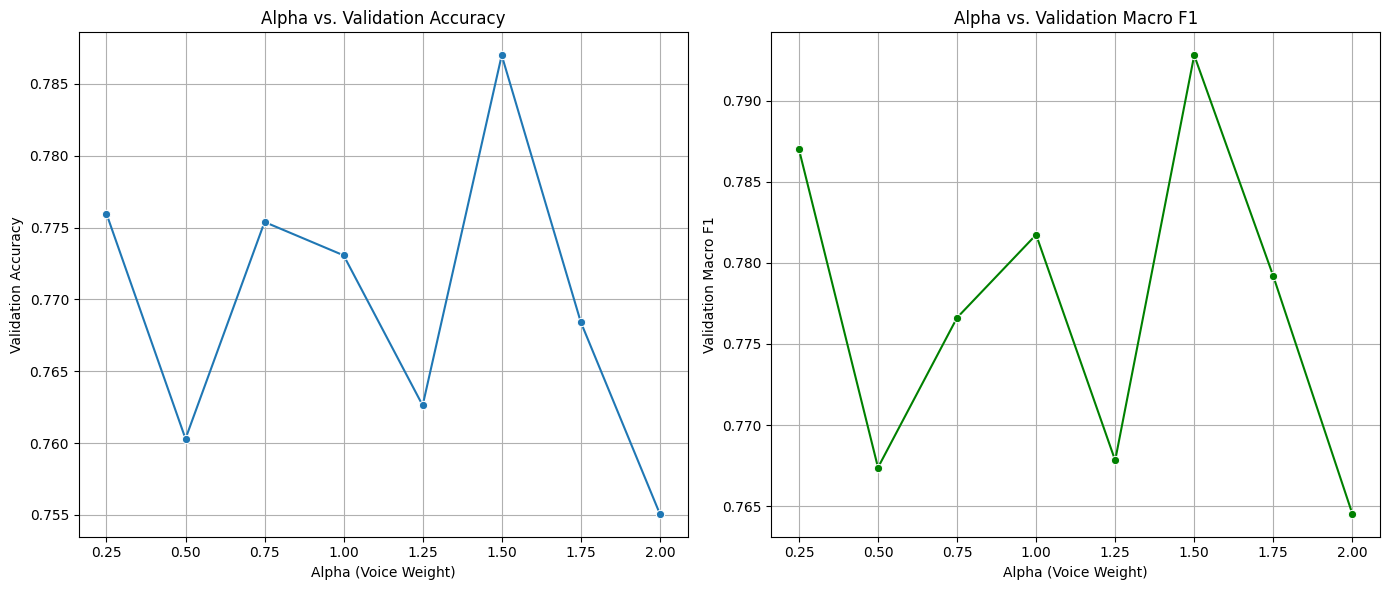

Plots saved to /content/drive/MyDrive/Fusion_Weight_Search_Output/alpha_vs_metrics.png


In [ ]:
results_df = pd.DataFrame(search_results)

# Sort by validation_macro_f1
results_df_sorted = results_df.sort_values(by='validation_macro_f1', ascending=False).reset_index(drop=True)

print("\nWeight Search Results (sorted by Validation Macro F1):")
display(results_df_sorted)

# Save to CSV
output_dir = '/content/drive/MyDrive/Fusion_Weight_Search_Output/'
os.makedirs(output_dir, exist_ok=True)
results_df_sorted.to_csv(f'{output_dir}weight_search_results.csv', index=False)
print(f"Results saved to {output_dir}weight_search_results.csv")

# Create plots
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(x='alpha', y='validation_accuracy', data=results_df_sorted, marker='o')
plt.title('Alpha vs. Validation Accuracy')
plt.xlabel('Alpha (Voice Weight)')
plt.ylabel('Validation Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.lineplot(x='alpha', y='validation_macro_f1', data=results_df_sorted, marker='o', color='green')
plt.title('Alpha vs. Validation Macro F1')
plt.xlabel('Alpha (Voice Weight)')
plt.ylabel('Validation Macro F1')
plt.grid(True)

plt.tight_layout()

# Save plot
plt.savefig(f'{output_dir}alpha_vs_metrics.png')
plt.show()
print(f"Plots saved to {output_dir}alpha_vs_metrics.png")

## PART 6 - Automatic Best Alpha

Automatically select the `best_alpha` based on the highest validation Macro F1 score.

In [ ]:
best_alpha_row = results_df_sorted.iloc[0]
best_alpha = best_alpha_row['alpha']

print(f"BEST ALPHA FOUND: {best_alpha:.2f}")
print(f"With Validation Macro F1: {best_alpha_row['validation_macro_f1']:.4f}")

# Save best alpha to a file
with open(f'{output_dir}best_alpha.txt', 'w') as f:
    f.write(str(best_alpha))
print(f"Best alpha saved to {output_dir}best_alpha.txt")

BEST ALPHA FOUND: 1.50
With Validation Macro F1: 0.7928
Best alpha saved to /content/drive/MyDrive/Fusion_Weight_Search_Output/best_alpha.txt


## PART 7 - Final Training

Train the final fusion model using the `best_alpha` found, incorporating Focal Loss, Class Weights, Batch Normalization, Dropout, and various callbacks for robust training.

Performing final training with best_alpha = 1.50
Calculated Class Weights for final training:
{0: np.float64(0.8811349693251533), 1: np.float64(0.8811349693251533), 2: np.float64(0.8811349693251533), 3: np.float64(0.8811349693251533), 4: np.float64(1.0370036101083033), 5: np.float64(0.8811349693251533), 6: np.float64(2.7686746987951807)}


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │       852,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 988,679 (3.77 MB)

 Trainable params: 987,143 (3.77 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/50
250/252 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4569 - loss: 1.2344
Epoch 1: val_accuracy improved from None to 0.65409, saving model to /content/drive/MyDrive/Fusion_Weight_Search_Output/final_fusion_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Fusion_Weight_Search_Output/final_fusion_model.keras
252/252 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5334 - loss: 0.9485 - val_accuracy: 0.6541 - val_loss: 0.5936 - learning_rate: 0.0010
Epoch 2/50
251/252 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6616 - loss: 0.5365
Epoch 2: val_accuracy improved from 0.65409 to 0.71619, saving model to /content/drive/MyDrive/Fusion_Weight_Search_Output/final_fusion_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Fusion_Weight_Search_Output/final_fusion_model.keras
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6711 - loss: 0.5237 - val_accuracy: 0.7162 - val_loss: 0.4275 - learning_rate: 0.0010
Epoch 3/50
250/252 ━━━━━━━━

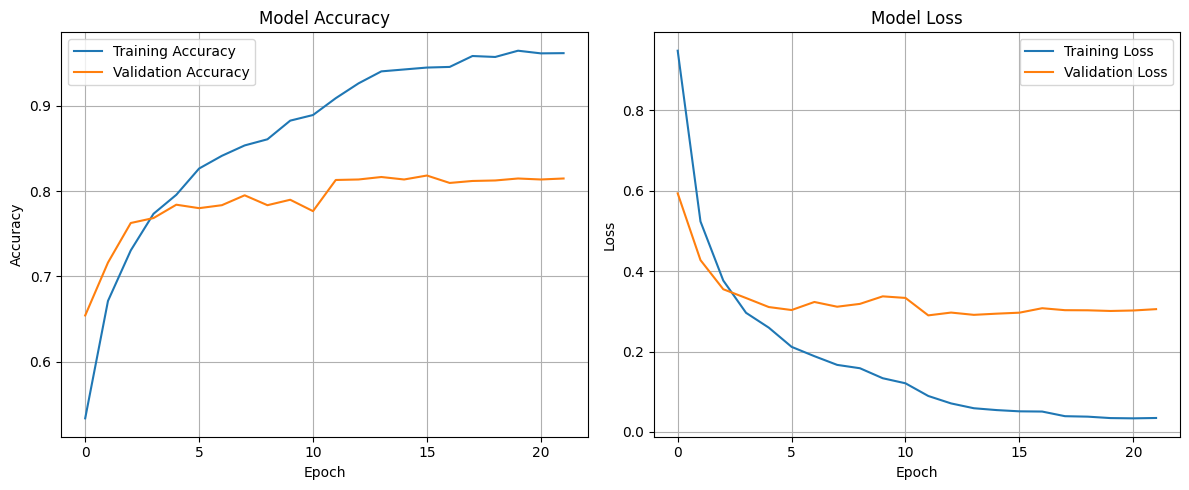

Training history plot saved to /content/drive/MyDrive/Fusion_Weight_Search_Output/training_history.png


In [ ]:
print(f"Performing final training with best_alpha = {best_alpha:.2f}")

# Create final fusion embeddings with the best alpha
fused_embs_final, fused_lbls_final = create_fused_dataset(face_embeddings, face_labels, voice_embeddings, voice_labels, alpha=best_alpha)

# Apply the fixed splits using the pre-calculated indices
X_train_final, y_train_final = fused_embs_final[train_indices], fused_lbls_final[train_indices]
X_val_final, y_val_final = fused_embs_final[val_indices], fused_lbls_final[val_indices]
X_test_final, y_test_final = fused_embs_final[test_indices], fused_lbls_final[test_indices]

# Standardize features using StandardScaler
final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train_final)
X_val_final_scaled = final_scaler.transform(X_val_final)
X_test_final_scaled = final_scaler.transform(X_test_final)

# Calculate class weights
class_weights_final = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_final),
    y=y_train_final
)
class_weight_dict_final = dict(enumerate(class_weights_final))
print("Calculated Class Weights for final training:")
print(class_weight_dict_final)

# Build the final model
input_dim_final = X_train_final_scaled.shape[1]
final_model = build_fusion_model(input_dim_final, num_classes)

# Define callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=f'{output_dir}final_fusion_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Compile the model
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss_fn,
    metrics=['accuracy']
)

final_model.summary()

# Train the model
epochs = 50 # Max epochs, early stopping will determine actual epochs
batch_size = 32

history_final = final_model.fit(
    X_train_final_scaled,
    y_train_final,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_final_scaled, y_val_final),
    class_weight=class_weight_dict_final,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

print("\nFinal model training complete.")

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final.history['accuracy'], label='Training Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_final.history['loss'], label='Training Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f'{output_dir}training_history.png')
plt.show()
print(f"Training history plot saved to {output_dir}training_history.png")

## PART 8 - Final Evaluation

Evaluate the best trained model on the unseen test set to assess its generalization performance.


Evaluating final model on the test set...


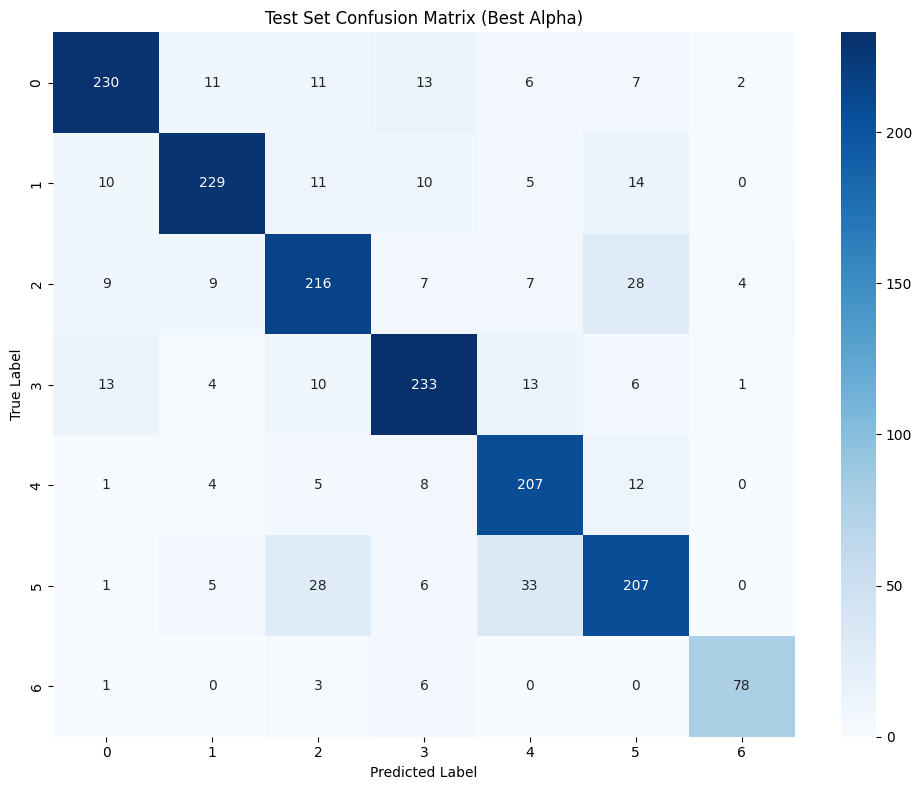

Confusion matrix plot saved to /content/drive/MyDrive/Fusion_Weight_Search_Output/confusion_matrix.png

Classification Report (Test Set, Best Alpha):
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       280
           1       0.87      0.82      0.85       279
           2       0.76      0.77      0.77       280
           3       0.82      0.83      0.83       280
           4       0.76      0.87      0.81       237
           5       0.76      0.74      0.75       280
           6       0.92      0.89      0.90        88

    accuracy                           0.81      1724
   macro avg       0.82      0.82      0.82      1724
weighted avg       0.81      0.81      0.81      1724


Final Test Set Performance (Best Alpha):
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       280
           1       0.87      0.82      0.85       279
           2       0.76      0.77      0.77     

In [ ]:
print("\nEvaluating final model on the test set...")

# Load the best model saved by ModelCheckpoint during final training
best_trained_model = tf.keras.models.load_model(
    f'{output_dir}final_fusion_model.keras',
    custom_objects={'SparseCategoricalFocalLoss': SparseCategoricalFocalLoss}
)

# Predict probabilities for the test set
y_pred_probs_test = best_trained_model.predict(X_test_final_scaled, verbose=0)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)

# Generate Confusion Matrix
cm_test = confusion_matrix(y_test_final, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=unique_classes, yticklabels=unique_classes)
plt.title('Test Set Confusion Matrix (Best Alpha)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f'{output_dir}confusion_matrix.png')
plt.show()
print(f"Confusion matrix plot saved to {output_dir}confusion_matrix.png")

# Generate Classification Report and F1 Scores
print("\nClassification Report (Test Set, Best Alpha):")
class_names = [str(cls) for cls in unique_classes]
print(classification_report(y_test_final, y_pred_test, target_names=class_names, zero_division=0))

test_accuracy, test_macro_f1, test_weighted_f1 = evaluate_model_performance(
    y_test_final, y_pred_test, unique_classes, description="Final Test Set Performance (Best Alpha)"
)

# Calculate Per-Class F1 Score
f1_per_class = f1_score(y_test_final, y_pred_test, average=None, zero_division=0)
print("\nPer-Class F1-Scores (Test Set, Best Alpha):")
for i, f1 in enumerate(f1_per_class):
    print(f"Class {unique_classes[i]} F1-Score: {f1:.4f}")

## PART 9 - Save Outputs

All relevant outputs from the weight search and final model training are saved to the specified output directory.

In [ ]:
# The following files have already been saved in previous steps:
# - `best_alpha.txt`
# - `weight_search_results.csv`
# - `alpha_vs_metrics.png` (plot of search results)
# - `final_fusion_model.keras` (the best trained model)
# - `training_history.png`
# - `confusion_matrix.png`

print(f"All required outputs have been saved to the directory: {output_dir}")

All required outputs have been saved to the directory: /content/drive/MyDrive/Fusion_Weight_Search_Output/


## PART 10 - Notebook Quality

This notebook is designed to run top-to-bottom, uses reusable functions, includes comments, and provides progress messages. It aims for production quality and does not overwrite the original `Fusion_Model.ipynb`.